# 재현 노트북: 카탈로그 임베딩 생성 -> 이미지 1장으로 Top-10 검색 + 시각화

최종 채택 모델(pretrained SigLIP2 so400m/patch14-384 + LoRA fine-tuning)을 이용해 이미지만으로
dresses 카탈로그에서 유사 상품 Top-10을 검색하고 시각화한다. 배포하는 모델은 LoRA 어댑터
(`weights/lora_v2_ema_mv_step0100/`, 약 8MB)뿐이며, 베이스 SigLIP2는 코드에서 Hugging Face
Hub(`google/siglip2-so400m-patch14-384`)로부터 자동으로 받아온다.

## 0. 환경

- Python 3.11, PyTorch 2.5(+cu121 GPU 권장, CPU도 동작은 하지만 느림)
  ```bash
  pip install torch transformers peft accelerate pillow pandas numpy matplotlib safetensors
  ```

## 1. 데이터 준비

카탈로그 메타데이터(`data/glami1m_dresses/catalog_items.csv`, `catalog_images.csv`)는 포함되어
있으나, 실제 이미지 파일(28,555장)은 용량 문제로 포함하지 않았다. `catalog_images.csv`를 참고하여
GLAMI-1M(https://huggingface.co/datasets/glami/glami-1m)에서 해당 이미지를 내려받아
`data/glami1m_dresses/images/<image_id>.jpg` 로 배치하면 된다 (`category_name == dresses`로 필터링된
32,434개 상품 / 28,555개 고유 이미지). 쿼리 이미지 예시 2장은 `sample_queries/`에 포함해 두었다.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd() / "src"))

import matplotlib.pyplot as plt
from PIL import Image

from config import PROJECT_ROOT, CATALOG_IMAGES_DIR
from catalog import (
    load_catalog_tables, build_or_load_catalog_embeddings, search_topk_items,
    load_full_pool_dedup, dedup_catalog_embeddings,
)
from siglip2_lora_encoder import Siglip2LoraEncoder

# 배포 모델: LoRA 어댑터만 (베이스 SigLIP2는 로드 시 HF Hub에서 자동 다운로드)
WEIGHTS_DIR = PROJECT_ROOT / "weights" / "lora_v2_ema_mv_step0100"
print("LoRA weights path:", WEIGHTS_DIR, "| exists:", WEIGHTS_DIR.exists())

C:\Users\hslee\anaconda3\envs\revit\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LoRA weights path: C:\jupyter\레브잇_과제\submission\weights\lora_v2_ema_mv_step0100 | exists: True


## 2. 모델 로드 (fine-tuned SigLIP2 = pretrained SigLIP2 + LoRA 어댑터)

In [2]:
encoder = Siglip2LoraEncoder(WEIGHTS_DIR)
print("encoder ready")

Loading weights:   0%|          | 0/448 [00:00<?, ?it/s]

Loading weights:  16%|█▌        | 71/448 [00:00<00:00, 667.14it/s]

Loading weights:  31%|███       | 138/448 [00:00<00:00, 507.18it/s]

Loading weights:  43%|████▎     | 191/448 [00:00<00:00, 424.07it/s]

Loading weights:  53%|█████▎    | 239/448 [00:00<00:00, 416.86it/s]

...

Loading weights:  84%|████████▎ | 375/448 [00:00<00:00, 406.95it/s]

Loading weights:  94%|█████████▍| 422/448 [00:00<00:00, 413.15it/s]

Loading weights: 100%|██████████| 448/448 [00:01<00:00, 431.07it/s]


[transformers] SiglipVisionModel LOAD REPORT from: google/siglip2-so400m-patch14-384
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...26}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}

encoder ready


## 3. 카탈로그 임베딩 생성 (최초 1회, 이후 자동 캐시 재사용)

`data/glami1m_dresses/images/`에 이미지가 준비되어 있어야 한다. 28,555장을 전부 인코딩하며,
결과는 `eval/embed_cache/lora_v2_ema_mv_step0100_catalog.pt`에 캐시되어 다음 실행부터는 즉시
로드된다. 근접중복(사실상 같은 사진) 이미지는 대표 이미지 하나로 축소해서 검색 후보로 쓴다
(`eval/results/full_pool_dedup.json`, 28,555 -> 28,102대표) - Top-10 중 여러 슬롯이 육안으로
구분 안 되는 같은 사진으로 낭비되지 않도록 하기 위함이다.

In [3]:
items_df, _ = load_catalog_tables()
image_ids, catalog_embeddings = build_or_load_catalog_embeddings(encoder, cache_name="lora_v2_ema_mv_step0100")

representative_of, representatives = load_full_pool_dedup()
if representatives:
    image_ids, catalog_embeddings = dedup_catalog_embeddings(image_ids, catalog_embeddings, representatives)

print(f"검색 후보(근접중복 제거 후): {len(image_ids)}장")

saved catalog embeddings -> C:\jupyter\레브잇_과제\submission\eval\embed_cache\lora_v2_ema_mv_step0100_catalog.pt (torch.Size([28555, 1152]))
검색 후보(근접중복 제거 후): 28102장


## 4. 이미지 1장 -> Top-10 검색 + 시각화

 1. image_id=5477     score=0.4884  item_ids=[5545]  Top Elegant Pouzdrové bavlněné šaty - GABI   krémová
 2. image_id=59200    score=0.4867  item_ids=[61458]  Goci Bundička a šaty Verona
 3. image_id=699878   score=0.4850  item_ids=[785353]  Glara Short lace ladies dress
 4. image_id=549      score=0.4754  item_ids=[560]  Bílé samodržící koktejlové šaty
 5. image_id=699951   score=0.4714  item_ids=[785451]  Haljina MUUV. boja: bijela
 6. image_id=5986     score=0.4710  item_ids=[6078]  Koktejlové mini šaty neon růžové
 7. image_id=5639     score=0.4693  item_ids=[5717]  TopMode Pouzdrové šaty s krajkou v horní části
 8. image_id=6311     score=0.4685  item_ids=[6406,551137]  YooY Jednobarevné šaty pro volný čas
 9. image_id=5641     score=0.4684  item_ids=[5719]  YooY Krátké pouzdrové šaty s kamínkovou aplikací
10. image_id=467792   score=0.4681  item_ids=[496062]  LOVEFASHIONPOINT Φόρεμα Mini


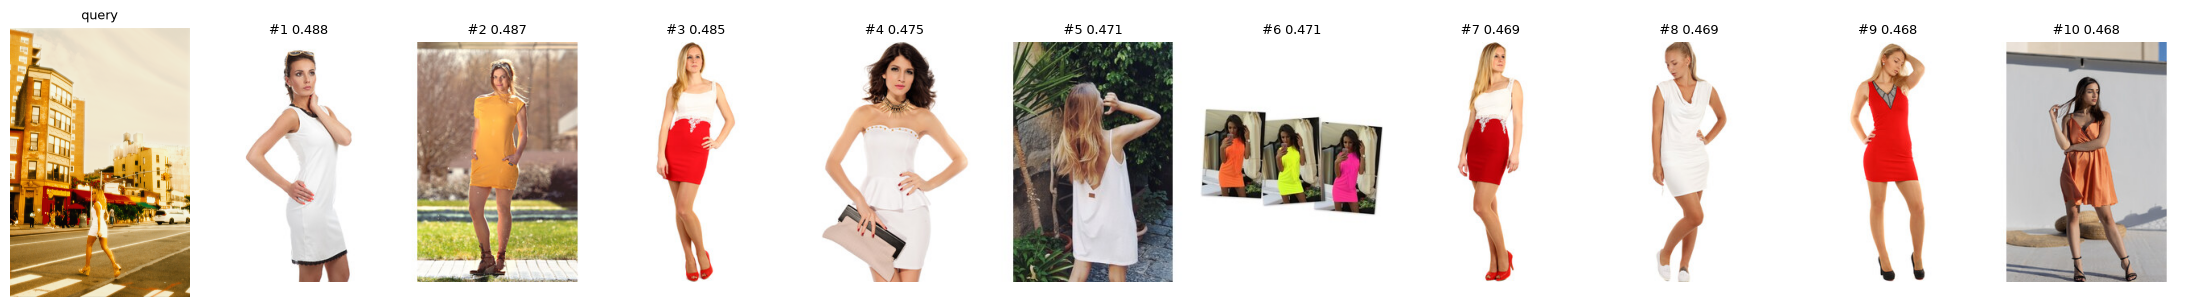

In [4]:
def search_top10(query_image_path):
    query_embedding = encoder.encode_images([query_image_path])[0]
    results = search_topk_items(
        query_embedding, image_ids, catalog_embeddings, items_df, k=10,
        representative_of=representative_of,
    )
    for r in results:
        item_ids_str = ",".join(str(i) for i in r["item_ids"])
        print(f"{r['rank']:>2}. image_id={r['image_id']:<8} score={r['score']:.4f}  item_ids=[{item_ids_str}]  {r['name']}")
    return results


def visualize_top10(query_image_path, results):
    fig, axes = plt.subplots(1, 11, figsize=(22, 3))
    axes[0].imshow(Image.open(query_image_path).convert("RGB"))
    axes[0].set_title("query", fontsize=9)
    axes[0].axis("off")
    for ax, r in zip(axes[1:], results):
        img_path = CATALOG_IMAGES_DIR / f"{r['image_id']}.jpg"
        ax.imshow(Image.open(img_path).convert("RGB"))
        ax.set_title(f"#{r['rank']} {r['score']:.3f}", fontsize=9)
        ax.axis("off")
    fig.tight_layout()
    plt.show()


QUERY_IMAGE_PATH = "sample_queries/001_17880654.jpg"  # 원하는 쿼리 이미지 경로로 교체 가능
results = search_top10(QUERY_IMAGE_PATH)
visualize_top10(QUERY_IMAGE_PATH, results)

 1. image_id=17872    score=0.6367  item_ids=[18317]  Šaty Fobya F735 bílé
 2. image_id=17870    score=0.6226  item_ids=[18315]  Šaty Fobya F737 bílé
 3. image_id=324339   score=0.6116  item_ids=[338777]  Creative Šaty - kód 8113 - 2 - biela
 4. image_id=516833   score=0.5813  item_ids=[551138]  Glara Short summer dress lace
 5. image_id=322745   score=0.5720  item_ids=[337076]  Dress LOLA ecru Dstreet EY1556
 6. image_id=89204    score=0.5699  item_ids=[92385]  Marko Ines Bianco M-387 Tunic 2
 7. image_id=89206    score=0.5671  item_ids=[92387]  Marko Judy Bianco M-444 tunic 1
 8. image_id=1053796  score=0.5606  item_ids=[1231134]  Manzara SUVEKLEIT LIZETTI valge
 9. image_id=53223    score=0.5599  item_ids=[55289]  NoName Plážové šaty na plavky bílé
10. image_id=732663   score=0.5593  item_ids=[1230037]  Manzara RANNAKLEIT AERITH valge


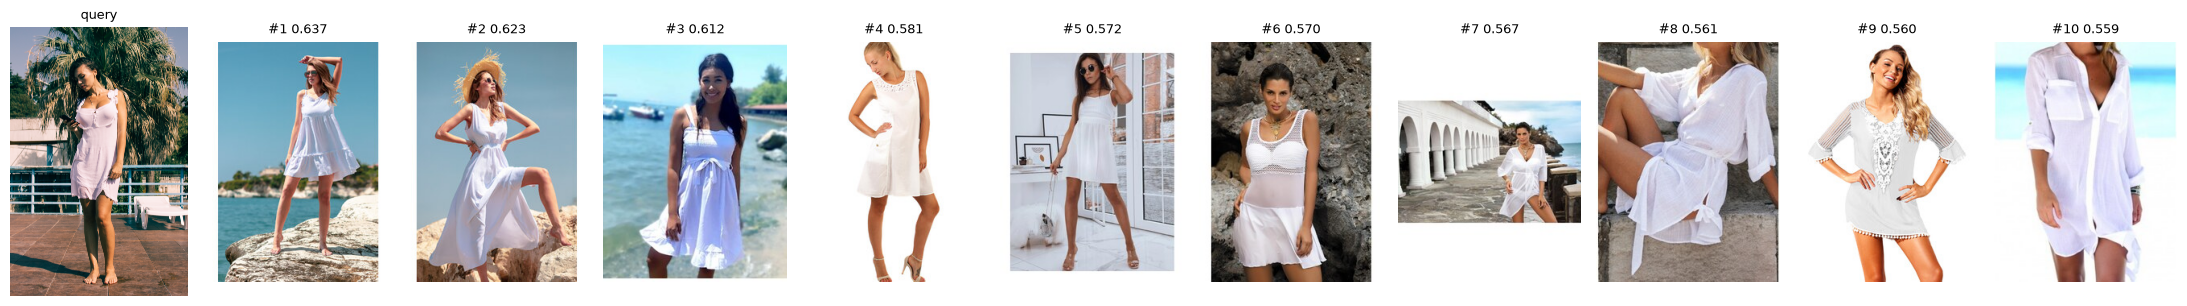

In [5]:
QUERY_IMAGE_PATH = "sample_queries/050_761986.jpg"
results = search_top10(QUERY_IMAGE_PATH)
visualize_top10(QUERY_IMAGE_PATH, results)